# Hands-On Module 2 — Analisis Fuel Efficiency (MPG Dataset)

**Nama:** Eka Suci Ramadhani
**NIM:** 18225063
**Program:** GDGoC ITB Career Path — AI Module 2

Notebook ini isinya analisis dataset MPG (fuel efficiency mobil) pakai NumPy, Pandas, Seaborn, dan Matplotlib. Tujuannya buat latihan nerapin konsep linear algebra, statistik, EDA, sama visualisasi yang udah dipelajari di Module 2, sekalian nyari tau faktor apa aja yang paling ngaruh ke efisiensi bahan bakar mobil.

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## Stage 1 — Inspection & Data Cleaning

### 1. Load dataset, cek shape, dtype, dan missing value

In [2]:
df = sns.load_dataset('mpg')

print("Shape dataset:", df.shape)
print()
print("Tipe data tiap kolom:")
print(df.dtypes)
print()
print("Jumlah missing value per kolom:")
print(df.isna().sum())

Shape dataset: (398, 9)

Tipe data tiap kolom:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Jumlah missing value per kolom:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


Dari hasil di atas, dataset ini punya 398 baris dan 9 kolom. Cuma ada 1 kolom yang punya missing value, yaitu **horsepower** (6 baris kosong dari 398). Kolom lain aman semua.

**Cara nanganin missing value:** aku pilih **drop baris** yang horsepower-nya kosong, bukan diisi (imputasi). Alasannya:
- Yang kosong cuma 6 baris dari 398 (~1.5%), jadi kalau di-drop dampaknya ke keseluruhan data kecil banget, gak bakal ngerusak distribusi.
- Horsepower itu salah satu fitur numerik penting yang mau dipakai buat analisis korelasi & regresi di tahap selanjutnya. Kalau diisi pakai mean/median, nilainya jadi "buatan" dan bisa bikin hasil korelasi/regresi sedikit bias, apalagi untuk fitur yang mungkin ada hubungan sama fitur lain (misal horsepower biasanya berkorelasi kuat sama displacement dan weight).
- Karena jumlahnya sedikit dan kemungkinan besar hilangnya random (bukan pola tertentu), drop row lebih aman dan simpel daripada nebak-nebak nilai yang hilang.

In [3]:
df_clean = df.dropna(subset=['horsepower']).reset_index(drop=True)

print("Shape sebelum cleaning:", df.shape)
print("Shape setelah cleaning :", df_clean.shape)
print("Baris yang di-drop     :", df.shape[0] - df_clean.shape[0])

Shape sebelum cleaning: (398, 9)
Shape setelah cleaning : (392, 9)
Baris yang di-drop     : 6


### 2. Summary table manual pakai NumPy (tanpa `.describe()`)

In [4]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

def summary_numpy(arr):
    """Hitung mean, median, std, IQR, dan jumlah outlier (metode IQR x 1.5) dari 1 array numpy."""
    mean = np.mean(arr)
    median = np.median(arr)
    std = np.std(arr, ddof=1)
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = np.sum((arr < lower) | (arr > upper))
    return mean, median, std, iqr, outlier_count

rows = []
for col in numeric_cols:
    arr = df_clean[col].to_numpy(dtype=float)
    mean, median, std, iqr, outlier_count = summary_numpy(arr)
    rows.append({
        'kolom': col,
        'mean': round(mean, 2),
        'median': round(median, 2),
        'std': round(std, 2),
        'IQR': round(iqr, 2),
        'jumlah_outlier': int(outlier_count)
    })

summary_df = pd.DataFrame(rows).set_index('kolom')
summary_df

,mean,median,std,IQR,jumlah_outlier
kolom,,,,,
mpg,23.45,22.75,7.81,12.00,0
cylinders,5.47,4.00,1.71,4.00,0
displacement,194.41,151.00,104.64,170.75,0
horsepower,104.47,93.50,38.49,51.00,10
weight,2977.58,2803.50,849.40,1389.50,0
acceleration,15.54,15.50,2.76,3.25,11
model_year,75.98,76.00,3.68,6.00,0


Dari tabel ini kelihatan kalau kolom **horsepower** dan **acceleration** punya beberapa outlier. Ini masuk akal karena ada mobil-mobil sport/high performance yang emang secara alami punya spek jauh di atas rata-rata mobil biasa (bukan error data).

## Stage 2 — Statistical Analysis dengan NumPy

### 3. Extract fitur numerik & standardisasi z-score (vectorized, tanpa loop)

In [5]:
features = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df_clean[features].to_numpy(dtype=float)

# Z-score standardisasi: (x - mean) / std, dilakukan langsung ke seluruh kolom (vectorized)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_standardized = (X - X_mean) / X_std

print("Rata-rata tiap kolom setelah standardisasi (harusnya ~0):")
print(np.round(X_standardized.mean(axis=0), 4))
print()
print("Std tiap kolom setelah standardisasi (harusnya ~1):")
print(np.round(X_standardized.std(axis=0, ddof=1), 4))

Rata-rata tiap kolom setelah standardisasi (harusnya ~0):
[ 0. -0. -0.  0.  0.]

Std tiap kolom setelah standardisasi (harusnya ~1):
[1. 1. 1. 1. 1.]


Standardisasinya berhasil, rata-rata tiap kolom udah mendekati 0 dan std-nya mendekati 1. Ini artinya semua fitur sekarang ada di skala yang sama, jadi nanti gampang dibandingin.

### 4. Correlation matrix 5 fitur numerik

In [6]:
corr_matrix_5 = np.corrcoef(X, rowvar=False)
corr_df = pd.DataFrame(corr_matrix_5, index=features, columns=features)
corr_df.round(3)

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000,-0.805,-0.778,-0.832,0.423
displacement,-0.805,1.000,0.897,0.933,-0.544
horsepower,-0.778,0.897,1.000,0.865,-0.689
weight,-0.832,0.933,0.865,1.000,-0.417
acceleration,0.423,-0.544,-0.689,-0.417,1.000


In [7]:
# Cari pasangan fitur dengan korelasi terkuat (selain diagonal)
corr_arr = corr_df.to_numpy(dtype=float).copy()
np.fill_diagonal(corr_arr, np.nan)
corr_no_diag = pd.DataFrame(corr_arr, index=corr_df.index, columns=corr_df.columns)

# (a) Pasangan dengan korelasi positif terkuat (keseluruhan matrix)
max_pos = corr_no_diag.stack().idxmax()
max_pos_val = corr_no_diag.stack().max()
print(f"(a) Korelasi positif terkuat  : {max_pos} = {max_pos_val:.3f}")

# (b) Fitur yang korelasi negatifnya paling kuat terhadap mpg
mpg_corr = corr_no_diag['mpg'].drop('mpg')
strongest_neg_to_mpg = mpg_corr.idxmin()
strongest_neg_val = mpg_corr.min()
print(f"(b) Korelasi negatif terkuat ke mpg : {strongest_neg_to_mpg} = {strongest_neg_val:.3f}")

# (c) Pasangan fitur INPUT (bukan mpg) yang paling berkorelasi -> potensi multikolinearitas
input_features = [f for f in features if f != 'mpg']
input_corr = corr_no_diag.loc[input_features, input_features]
max_input_pair = input_corr.stack().idxmax()
max_input_val = input_corr.stack().max()
print(f"(c) Pasangan input feature paling berkorelasi (potensi multikolinearitas): {max_input_pair} = {max_input_val:.3f}")

(a) Korelasi positif terkuat  : ('displacement', 'weight') = 0.933
(b) Korelasi negatif terkuat ke mpg : weight = -0.832
(c) Pasangan input feature paling berkorelasi (potensi multikolinearitas): ('displacement', 'weight') = 0.933


**Interpretasi:**
- **(a)** Korelasi positif paling kuat ada di pasangan **displacement–weight**. Ini masuk akal karena mobil dengan mesin (displacement) lebih besar biasanya juga lebih berat bodinya.
- **(b)** Fitur yang paling negatif korelasinya sama mpg adalah **weight**. Artinya makin berat mobilnya, makin boros bahan bakarnya (mpg makin turun).
- **(c)** Pasangan **displacement–weight** juga jadi kandidat kuat multikolinearitas antar input feature, artinya kedua fitur ini bawa informasi yang mirip-mirip. Kalau dipakai bareng-bareng buat model regresi, salah satunya jadi agak redundan.

### 5. Boolean masking — horsepower di atas rata-rata vs weight

In [8]:
hp = df_clean['horsepower'].to_numpy(dtype=float)
wt = df_clean['weight'].to_numpy(dtype=float)

mean_hp = hp.mean()
mean_wt = wt.mean()

mask_above_avg_hp = hp > mean_hp

avg_weight_above_avg_hp = wt[mask_above_avg_hp].mean()
avg_weight_overall = wt.mean()
diff = avg_weight_above_avg_hp - avg_weight_overall

print(f"Rata-rata horsepower keseluruhan          : {mean_hp:.1f}")
print(f"Jumlah mobil dengan horsepower > rata-rata: {mask_above_avg_hp.sum()} dari {len(hp)}")
print(f"Rata-rata weight mobil ber-horsepower tinggi : {avg_weight_above_avg_hp:.1f} lbs")
print(f"Rata-rata weight seluruh dataset              : {avg_weight_overall:.1f} lbs")
print(f"Selisih absolut                                : {abs(diff):.1f} lbs")

Rata-rata horsepower keseluruhan          : 104.5
Jumlah mobil dengan horsepower > rata-rata: 148 dari 392
Rata-rata weight mobil ber-horsepower tinggi : 3815.5 lbs
Rata-rata weight seluruh dataset              : 2977.6 lbs
Selisih absolut                                : 837.9 lbs


Iya, terbukti mobil dengan horsepower di atas rata-rata memang cenderung lebih berat dibanding rata-rata dataset — selisihnya lumayan besar. Ini nyambung sama temuan korelasi sebelumnya: horsepower, weight, dan displacement itu saling berkaitan, mobil yang mesinnya lebih besar (lebih bertenaga) biasanya juga punya bodi yang lebih berat.

## Stage 3 — Visualisasi

### 6. Distribusi MPG (histogram + KDE)

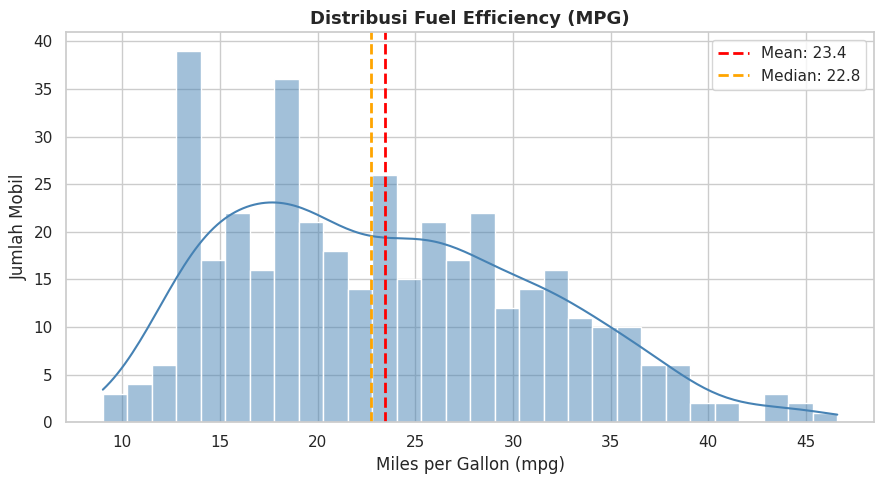

Mean mpg   : 23.45
Median mpg : 22.75


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df_clean['mpg'], bins=30, kde=True, ax=ax, color='steelblue')

mean_mpg = df_clean['mpg'].mean()
median_mpg = df_clean['mpg'].median()

ax.axvline(mean_mpg, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_mpg:.1f}')
ax.axvline(median_mpg, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_mpg:.1f}')

ax.set_title('Distribusi Fuel Efficiency (MPG)', fontsize=13, fontweight='bold')
ax.set_xlabel('Miles per Gallon (mpg)')
ax.set_ylabel('Jumlah Mobil')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean mpg   : {mean_mpg:.2f}")
print(f"Median mpg : {median_mpg:.2f}")

**Interpretasi:** mean (23.4) lebih besar dari median (22.75), dan kalau dilihat bentuk histogramnya ada ekor yang lebih panjang ke kanan. Jadi distribusi mpg ini **skewed ke kanan (right-skewed)**, bukan simetris. Artinya sebagian besar mobil punya mpg di kisaran menengah, tapi ada beberapa mobil yang mpg-nya jauh lebih tinggi dari kebanyakan (mobil yang irit banget), yang narik mean jadi lebih besar dari median.

### 7. Perbandingan MPG per Origin (boxplot)

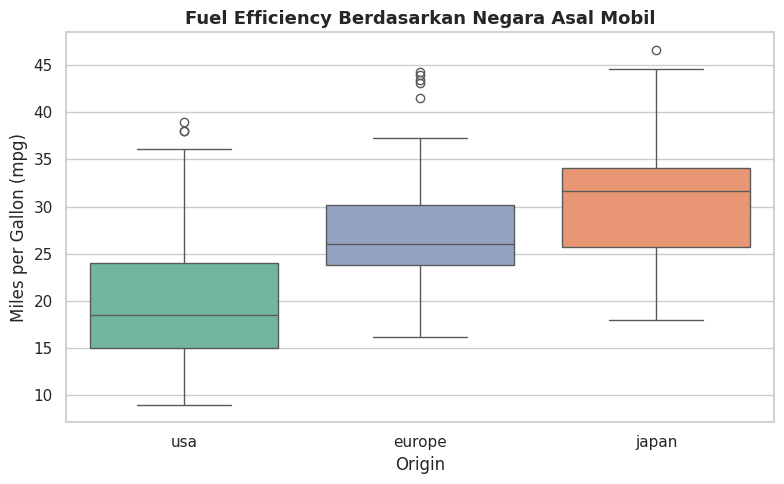

         mean  median   std
origin                     
europe  27.60    26.0  6.58
japan   30.45    31.6  6.09
usa     20.03    18.5  6.44


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_clean, x='origin', y='mpg', hue='origin', palette='Set2', ax=ax,
            order=['usa', 'europe', 'japan'], legend=False)

ax.set_title('Fuel Efficiency Berdasarkan Negara Asal Mobil', fontsize=13, fontweight='bold')
ax.set_xlabel('Origin')
ax.set_ylabel('Miles per Gallon (mpg)')

plt.tight_layout()
plt.show()

print(df_clean.groupby('origin')['mpg'].agg(['mean', 'median', 'std']).round(2))

**Interpretasi:** dari boxplot dan tabel di atas, mobil buatan **Japan** punya median dan mean mpg paling tinggi dibanding USA dan Europe, jadi Japan yang paling fuel-efficient. Mobil USA punya mpg paling rendah dan sebarannya juga relatif rapat (konsisten rendah). Europe ada di tengah-tengah, tapi range-nya (IQR) sedikit lebih lebar dibanding Japan, jadi hasilnya nggak sekonsisten Japan.

### 8. Weight vs MPG (scatter + trend line manual)

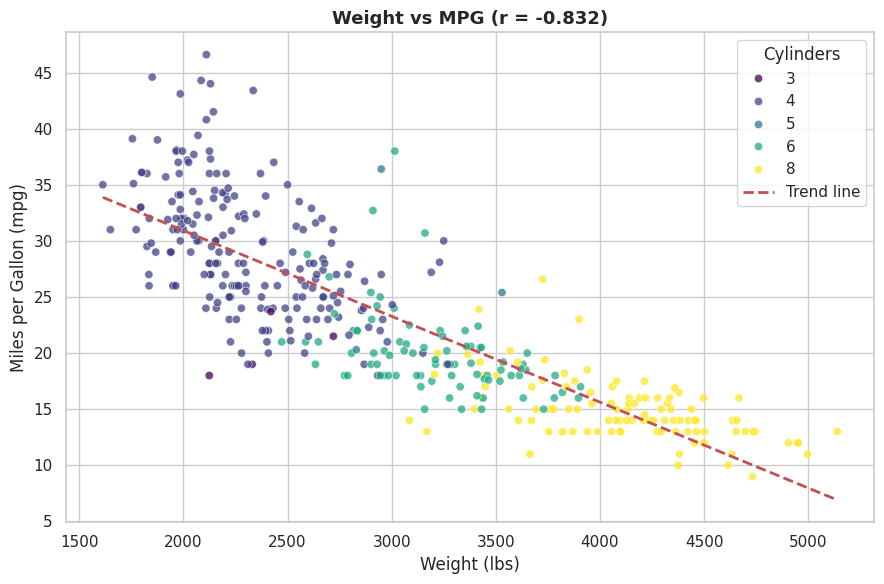

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(data=df_clean, x='weight', y='mpg', hue='cylinders', palette='viridis', alpha=0.75, ax=ax)

# Trend line manual pakai np.polyfit
z = np.polyfit(df_clean['weight'], df_clean['mpg'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['weight'].min(), df_clean['weight'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')

r_value = df_clean['weight'].corr(df_clean['mpg'])

ax.set_title(f'Weight vs MPG (r = {r_value:.3f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon (mpg)')
ax.legend(title='Cylinders')

plt.tight_layout()
plt.show()

**Interpretasi:** korelasinya negatif kuat (r sekitar -0.83). Makin berat mobilnya, makin rendah mpg-nya — polanya jelas banget dari trend line yang menurun. Kalau dilihat dari warna (jumlah cylinder), mobil dengan cylinder lebih banyak (8) cenderung ngumpul di area weight tinggi & mpg rendah, sedangkan cylinder 4 ngumpul di weight rendah & mpg tinggi. Jadi weight, cylinder, dan mpg ini saling berkaitan erat.

### 9. Correlation Heatmap

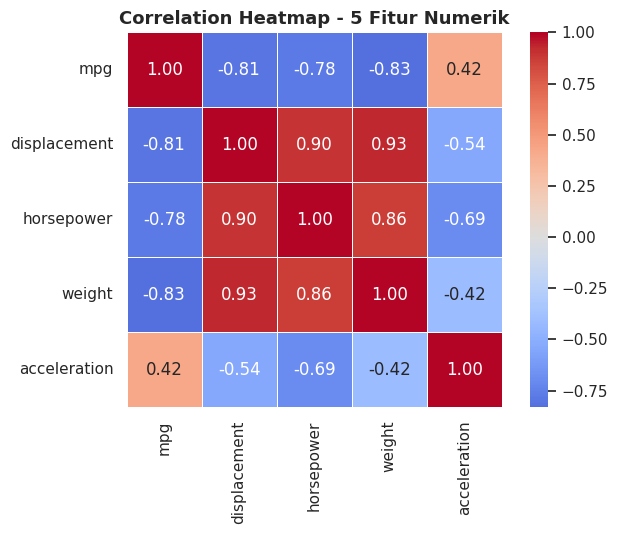

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax,
            linewidths=0.5)

ax.set_title('Correlation Heatmap - 5 Fitur Numerik', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretasi:** dari heatmap ini kelihatan jelas ada **multikolinearitas** antara **displacement, horsepower, dan weight** — ketiganya saling berkorelasi positif kuat (di atas 0.8), yang artinya mereka membawa informasi yang mirip (mobil bermesin besar = tenaga besar = berat). Sementara itu ketiganya sama-sama berkorelasi negatif kuat terhadap **mpg**. Kalau ketiga fitur ini semua dipakai bareng di model regresi linear, bisa bikin model jadi kurang stabil karena redundan.

## Stage 4 — Interpretasi Kontekstual

### 10. Faktor apa yang paling kuat memprediksi fuel efficiency?

Berdasarkan keseluruhan analisis di atas, faktor yang paling kuat memprediksi fuel efficiency (mpg) adalah **weight (berat mobil)**, diikuti erat oleh **displacement** dan **horsepower**. Ini didukung oleh beberapa temuan:

- Korelasi weight terhadap mpg adalah yang paling negatif kuat di antara semua fitur (sekitar **-0.83**), lebih kuat dibanding displacement maupun horsepower terhadap mpg.
- Dari scatter plot weight vs mpg, polanya jelas dan konsisten menurun — trend line-nya nunjukin hubungan linear negatif yang kuat.
- Dari boxplot per origin, mobil-mobil USA (yang cenderung lebih berat, banyak V8/cylinder besar) punya mpg paling rendah, sedangkan Japan (mobil lebih ringan) punya mpg paling tinggi.
- Boolean masking di Stage 2 juga nunjukin kalau mobil dengan horsepower tinggi otomatis juga lebih berat, jadi weight ini semacam "akar" dari beberapa fitur lain yang saling berkorelasi.

Jadi kesimpulannya: **semakin berat sebuah mobil, semakin boros bahan bakarnya**, dan weight ini jadi fitur single yang paling representatif untuk memprediksi mpg dibanding fitur-fitur lain yang notabene juga berkorelasi kuat sama weight itu sendiri (multikolinearitas).

### 11. Rata-rata MPG per dekade

decade
1970    21.08
1980    31.98
Name: mpg, dtype: float64


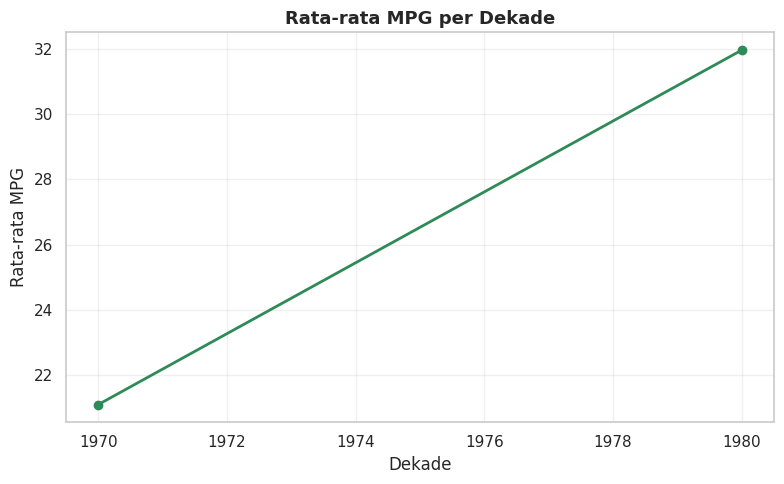

In [13]:
df_clean['decade'] = (df_clean['model_year'].apply(lambda y: (y // 10) * 10) + 1900)

mpg_per_decade = df_clean.groupby('decade')['mpg'].mean()
print(mpg_per_decade.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
mpg_per_decade.plot(kind='line', marker='o', ax=ax, color='seagreen', linewidth=2)

ax.set_title('Rata-rata MPG per Dekade', fontsize=13, fontweight='bold')
ax.set_xlabel('Dekade')
ax.set_ylabel('Rata-rata MPG')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretasi:** rata-rata mpg naik terus dari dekade 1970-an ke 1980-an. Kemungkinan penyebabnya adalah krisis minyak dunia di tahun 1970-an yang bikin produsen mobil mulai fokus bikin mesin yang lebih efisien, ditambah regulasi emisi & standar efisiensi bahan bakar (seperti CAFE standard di Amerika) yang mulai diberlakukan sekitar era itu. Jadi tren naiknya mpg dari waktu ke waktu ini nunjukin perubahan fokus industri otomotif dari "tenaga besar" ke "efisiensi", sejalan juga sama temuan sebelumnya bahwa mobil yang lebih ringan dan berdisplacement kecil itu lebih irit.

## Kesimpulan

Dari seluruh analisis di notebook ini, bisa disimpulkan:

1. Dataset MPG cukup bersih, cuma butuh drop 6 baris karena missing value di kolom horsepower.
2. Distribusi mpg **right-skewed**, bukan normal sempurna.
3. Mobil **Japan** paling fuel-efficient, USA paling boros.
4. **Weight** adalah prediktor terkuat terhadap mpg, dan berkorelasi erat dengan displacement & horsepower (multikolinearitas).
5. Rata-rata mpg terus naik dari dekade 1970 ke 1980-an, kemungkinan besar dipengaruhi krisis minyak dan regulasi efisiensi bahan bakar.